In [36]:
!pip install scikit-learn seaborn pymfe -q

In [37]:
import warnings
from time import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from pymfe.mfe import MFE
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import (
    GridSearchCV,
    LeaveOneOut,
    ParameterGrid,
    StratifiedKFold,
    cross_validate,
    )
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, RobustScaler, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

## Passo 1: Obter conjunto de datasets de treinamento

In [38]:
# #Carregando os datasets
# from sklearn.datasets import fetch_openml

# names = ['diabetes', 'blood-transfusion-service-center',
#          'monks-problems-2', 'tic-tac-toe', 'titanic', 'pc1',
#          'kr-vs-kp', 'phoneme', 'wdbc', 'semeion', 'isolet',
#          'cnae-9', 'ilpd-numeric', 'students_scores',
#          'usps', 'ibm-employee-performance','mushroom',
#          'segment',  'autoUniv-au1-1000', 'pizzacutter3', 
#          'qsar', 'solar-flare']

# #errors: 'sick-numeric', 'telco-custumer-churn', 'credit-g', 'anneal'
# #Too big: 'kits'

# datasets = {} 
# for name in names:
#     print('Fetching dataset: {}'.format(name))
#     datasets[name] = fetch_openml(name=name, as_frame=True)

# print(f'Finished fetching {len(datasets)} datasets.')


## Passo 1.1: Obter conjunto de datasets complementares

In [39]:
# # Carregando datasets complementares
# complementary_names = [
#     'adult', 'credit-g', 'bank-marketing', 
#     'madelon', 'spambase', 'yeast', 
#     'ionosphere', 'steel-plates-fault', 'gas-drift',
#     'nursery', 'car', 'heart-statlog'
# ]

# complementary_datasets = {} 
# for name in complementary_names:
#     print('Fetching complementary dataset: {}'.format(name))
#     try:
#         complementary_datasets[name] = fetch_openml(name=name, as_frame=True)
#     except Exception as e:
#         print(f'Error fetching {name}: {e}')

# print(f'Finished fetching {len(complementary_datasets)} complementary datasets.')

## Passo 1.2: Combinar todos os datasets

In [40]:
# # Combinar datasets originais e complementares
# all_datasets = {**datasets, **complementary_datasets}
# all_names = names + list(complementary_datasets.keys())

# print(f'Total datasets: {len(all_datasets)}')
# print(f'Original datasets: {len(datasets)}')
# print(f'Complementary datasets: {len(complementary_datasets)}')

## Passo 2: Avaliar performance dos classificadores nos datasets

In [41]:
# # Define classifiers
# from sklearn.impute import SimpleImputer


# classifiers = {
#     'DecisionTree': DecisionTreeClassifier(random_state=42),
#     'SVM': SVC(random_state=42),
#     'KNN': KNeighborsClassifier(),
#     'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000),
#     'Perceptron': Perceptron(random_state=42, max_iter=1000),
#     'MLP': MLPClassifier(random_state=42, max_iter=1000)
# }

# # Store results
# results = []

# # Iterate through ALL datasets (original + complementary)
# for dataset_name in all_names:
#     print(f'Processing dataset: {dataset_name}')
    
#     # Determine dataset group for comparison
#     dataset_group = 'Original' if dataset_name in names else 'Complementary'
    
#     # Get data and target
#     X = all_datasets[dataset_name]['data']
#     y = all_datasets[dataset_name]['target']
    
#     # Handle missing values
#     imputer = KNNImputer(n_neighbors=3)
#     try:
#         X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
#     except Exception as e:
#         print(f'Warning: Imputation failed for {dataset_name} with error: {e}')
#         print('Falling back to simple imputation strategy.')
#         # Use most frequent strategy for string/categorical data
#         imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
#         # Fit and transform the data
#         X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)


#     # Handle categorical features
#     for col in X.select_dtypes(include=['object']).columns:
#         le = LabelEncoder()
#         X[col] = le.fit_transform(X[col].astype(str))
    
#     # Encode target if necessary
#     if y.dtype == 'object':
#         le = LabelEncoder()
#         y = le.fit_transform(y)
    
#     # Evaluate each classifier
#     for clf_name, clf in classifiers.items():
#         print(f'  Evaluating {clf_name}...', end=' ')
        
#         # 5-fold cross validation
#         cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#         cv_results = cross_validate(clf, X, y, cv=cv, scoring='accuracy', 
#                                     return_train_score=False)
        
#         # Extract fold accuracies
#         fold_accs = cv_results['test_score']
        
#         # Create result row
#         result_row = {
#             'Dataset': dataset_name,
#             'Group': dataset_group,
#             'Classifier': clf_name,
#             'acc_fold1': fold_accs[0],
#             'acc_fold2': fold_accs[1],
#             'acc_fold3': fold_accs[2],
#             'acc_fold4': fold_accs[3],
#             'acc_fold5': fold_accs[4],
#             'acc_mean': fold_accs.mean(),
#             'acc_stddev': fold_accs.std(),
#             'train_time': cv_results['fit_time'].sum(),
#             'test_time': cv_results['score_time'].sum()
#         }
        
#         results.append(result_row)
#         print('Done')

# # Create results DataFrame
# performances_df = pd.DataFrame(results)

In [42]:
# performances_df

## Passo 3: Extrair meta-features dos datasets

In [43]:
# # Extract meta-features from ALL datasets (original + complementary)
# meta_features = []

# for dataset_name in all_names:  
#     print(f'Extracting meta-features from {dataset_name}...', end=' ')
    
#     # Get data and target
#     X = all_datasets[dataset_name]['data']
#     y = all_datasets[dataset_name]['target']
    
#     # Handle categorical features
#     for col in X.select_dtypes(include=['object']).columns:
#         le = LabelEncoder()
#         X[col] = le.fit_transform(X[col].astype(str))
    
#     # Handle missing values
#     imputer = KNNImputer(n_neighbors=3)
#     try:
#         X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
#     except Exception as e:
#         imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
#         X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
    
#     # Encode target if necessary
#     if y.dtype == 'object':
#         le = LabelEncoder()
#         y = le.fit_transform(y)
#     else:
#         # Convert to numpy array if it's a pandas Series
#         y = np.array(y)
    
#     # Extract meta-features
#     try:
#         mfe = MFE(groups=["general", "statistical", "info-theory", 
#                           "clustering", #"concept", "model_based", "landmarking", "complexity",
#                           ], summary='mean')
#         mfe.fit(X.values, y)
#         ft = mfe.extract()
        
#         # Create result row with dataset name and meta-features
#         result_row = {'dataset': dataset_name}
        
#         meta_features.append(pd.DataFrame(dict(zip(ft[0], ft[1])), index=[dataset_name]))
#         print('Done')
#     except Exception as e:
#         print(f'Error: {e}')

# # Create meta-features DataFrame
# meta_features_df = pd.concat(meta_features, ignore_index=False)

In [44]:
# meta_features_df

# Passo 4: Combinar as meta-features e as performances

In [45]:
# performances_df

In [46]:
# # Reshape performances_df to have one row per dataset and the performance (acc_mean) of each classifier as a separate column
# performances_df2 = performances_df.pivot(index='Dataset', columns='Classifier', values='acc_mean')
# performances_df2.columns.name = None
# performances_df2 = performances_df2.reset_index()
# performances_df2

In [47]:
# # Merge performances_df2 with meta_features_df based on dataset name
# meta_dataset = performances_df2.merge(
#     right=meta_features_df, 
#     left_on='Dataset', 
#     right_index=True, 
#     how='left'
# )

# # Reorder columns: 'Dataset' first, then meta-features, then classifiers
# meta_cols = meta_features_df.columns.tolist()
# classifier_cols = performances_df2.columns.drop('Dataset').tolist()
# meta_dataset = meta_dataset[['Dataset'] + meta_cols + classifier_cols]

In [48]:
# meta_dataset

In [49]:
# # Get the classifier columns (last 6 columns)
# classifier_cols = meta_dataset.columns[-6:].tolist()

# # Find the classifier with the best (maximum) accuracy for each dataset
# meta_dataset['Best'] = meta_dataset[classifier_cols].idxmax(axis=1)

In [50]:
# # Add Group column to identify original vs complementary datasets
# meta_dataset['Group'] = meta_dataset['Dataset'].apply(
#     lambda x: 'Original' if x in names else 'Complementary'
# )

# # Save meta_dataset to CSV for future use
# meta_dataset.to_csv('meta_dataset.csv', index=False)
# print(f'meta_dataset saved to meta_dataset.csv with {len(meta_dataset)} rows')

In [51]:
complete_meta_dataset = pd.read_csv('meta_dataset.csv')

#removing the complementary datasets to get base performance of the original datasets
meta_dataset = complete_meta_dataset[complete_meta_dataset['Group'] == 'Original']

#removing the Group column as it's no longer needed
meta_dataset = meta_dataset.drop(columns=['Group']).reset_index(drop=True)
complete_meta_dataset = complete_meta_dataset.drop(columns=['Group']).reset_index(drop=True)

# Define meta_cols and classifier_cols based on the loaded dataset
classifier_cols = ['DecisionTree', 'KNN', 'MLP', 'Perceptron', 'SVM', 'LogisticRegression']
meta_cols = [col for col in meta_dataset.columns if col not in ['Dataset', 'Best'] + classifier_cols]

# Recreate performances_df2 from the loaded data (only Dataset + classifier columns)
performances_df2 = meta_dataset[['Dataset'] + classifier_cols].copy()
complete_performances_df2 = complete_meta_dataset[['Dataset'] + classifier_cols].copy()

# Recreate other needed variables for downstream cells
names = meta_dataset['Dataset'].tolist()
complementary_names = complete_meta_dataset[~complete_meta_dataset['Dataset'].isin(names)]['Dataset'].tolist()
all_names = names + complementary_names

# Recreate classifiers dict (needed for summary cells)
classifiers = {
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'KNN': KNeighborsClassifier(),
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000),
    'Perceptron': Perceptron(random_state=42, max_iter=1000),
    'MLP': MLPClassifier(random_state=42, max_iter=1000)
}

In [52]:
pd.DataFrame(meta_dataset['Best'].value_counts())

,count
Best,
MLP,6
DecisionTree,6
LogisticRegression,5
SVM,4
KNN,1


# 5: Treinar (e avaliar) o meta-modelo (Datasets Base)

In [53]:
# Create a dictionary to store the reuslts:
summary_of_predictions = {'Dataset':[], 'Best clf (true)':[], 'Perf of best clf (true)':[],
                           'Best clf (pred)':[], 'Perf of best clf (pred)':[]}

loo = LeaveOneOut()
feat_import_perf_fold = []
y_true = meta_dataset['Best'].values
y_pred = []

for train_index, test_index in loo.split(meta_dataset):
    # Split the data into training and test sets
    X = meta_dataset.drop(columns=['Dataset', 'Best'] + classifier_cols) # Drop everything except meta-features
    y = meta_dataset['Best']
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train a simple classifier (e.g., Decision Tree) on the training set
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train)
    
    # Predict the best classifier for the test dataset
    y_pred.append(clf.predict(X_test)[0])
    
    # Store results in the summary dictionary
    summary_of_predictions['Dataset'].append(meta_dataset['Dataset'].iloc[test_index].values[0])
    summary_of_predictions['Best clf (true)'].append(y_test.values[0])
    summary_of_predictions['Perf of best clf (true)'].append(meta_dataset.loc[test_index, y_test.values[0]].values[0])
    summary_of_predictions['Best clf (pred)'].append(y_pred[-1])
    summary_of_predictions['Perf of best clf (pred)'].append(meta_dataset.loc[test_index, y_pred[-1]].values[0])


# Create a DataFrame from the summary of predictions
base_summary_df_no_scaler = pd.DataFrame(summary_of_predictions)

# Calculate meta-model accuracy and F1-score for BASE datasets
base_meta_model_accuracy_no_scaler = accuracy_score(y_true, y_pred)
base_meta_model_f1_no_scaler = f1_score(y_true, y_pred, average='weighted')
print(f'Meta-model Accuracy (No Scaler): {base_meta_model_accuracy_no_scaler:.2f}')
print(f'Meta-model F1-score (No Scaler): {base_meta_model_f1_no_scaler:.2f}')
print("-" * 30)


Meta-model Accuracy (No Scaler): 0.23
Meta-model F1-score (No Scaler): 0.21
------------------------------


In [54]:
base_summary_df_no_scaler

,Dataset,Best clf (true),Perf of best clf (true),Best clf (pred),Perf of best clf (pred)
0,autoUniv-au1-1000,SVM,0.758000,DecisionTree,0.649000
1,blood-transfusion-service-center,LogisticRegression,0.772707,LogisticRegression,0.772707
2,cnae-9,MLP,0.955556,DecisionTree,0.864815
3,diabetes,LogisticRegression,0.770792,DecisionTree,0.700433
4,ibm-employee-performance,DecisionTree,1.000000,LogisticRegression,0.962585
5,ilpd-numeric,LogisticRegression,0.718700,LogisticRegression,0.718700
6,isolet,MLP,0.961396,SVM,0.961139
7,kr-vs-kp,DecisionTree,0.995620,MLP,0.993742
8,monks-problems-2,DecisionTree,0.991667,MLP,0.750441
9,mushroom,DecisionTree,1.000000,DecisionTree,1.000000


In [55]:
# Base-level performance:
base_summary_df_no_scaler.describe()


,Perf of best clf (true),Perf of best clf (pred)
count,22.000000,22.000000
mean,0.893706,0.855740
std,0.094076,0.106370
min,0.718700,0.649000
25%,0.812109,0.773684
50%,0.925093,0.866907
75%,0.964050,0.954295
max,1.000000,1.000000


In [56]:
final_summary = pd.concat([performances_df2, base_summary_df_no_scaler], axis=1)
final_summary


,Dataset,DecisionTree,KNN,MLP,Perceptron,SVM,LogisticRegression,Dataset,Best clf (true),Perf of best clf (true),Best clf (pred),Perf of best clf (pred)
0,autoUniv-au1-1000,0.649000,0.734000,0.703000,0.697000,0.758000,0.735000,autoUniv-au1-1000,SVM,0.758000,DecisionTree,0.649000
1,blood-transfusion-service-center,0.709852,0.762058,0.673942,0.636385,0.759365,0.772707,blood-transfusion-service-center,LogisticRegression,0.772707,LogisticRegression,0.772707
2,cnae-9,0.864815,0.854630,0.955556,0.927778,0.919444,0.940741,cnae-9,MLP,0.955556,DecisionTree,0.864815
3,diabetes,0.700433,0.697869,0.658925,0.575333,0.760368,0.770792,diabetes,LogisticRegression,0.770792,DecisionTree,0.700433
4,ibm-employee-performance,1.000000,0.829252,0.904082,0.814966,0.846259,0.962585,ibm-employee-performance,DecisionTree,1.000000,LogisticRegression,0.962585
5,ilpd-numeric,0.638093,0.674138,0.704907,0.663719,0.713557,0.718700,ilpd-numeric,LogisticRegression,0.718700,LogisticRegression,0.718700
6,isolet,0.813775,0.890984,0.961396,0.947671,0.961139,0.960241,isolet,MLP,0.961396,SVM,0.961139
7,kr-vs-kp,0.995620,0.958075,0.993742,0.940232,0.973092,0.960576,kr-vs-kp,DecisionTree,0.995620,MLP,0.993742
8,monks-problems-2,0.991667,0.595647,0.750441,0.603912,0.677204,0.640606,monks-problems-2,DecisionTree,0.991667,MLP,0.750441
9,mushroom,1.000000,0.998769,1.000000,0.887494,0.990399,0.955687,mushroom,DecisionTree,1.000000,DecisionTree,1.000000


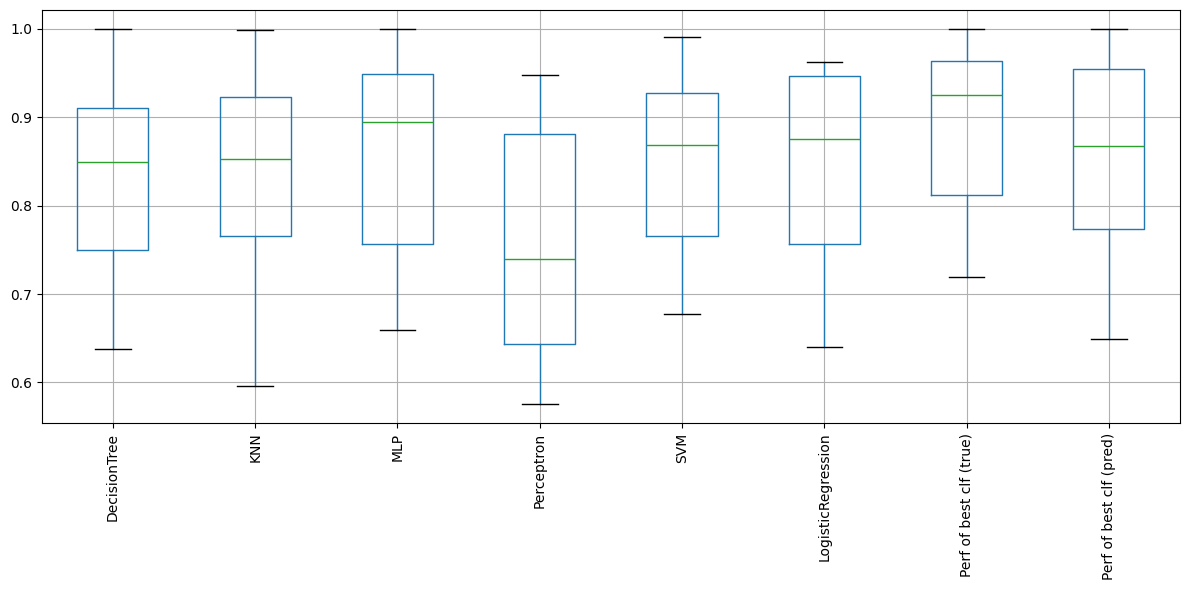

In [57]:
plt.figure(figsize=(12, 6))
final_summary.boxplot(rot=90)
plt.tight_layout()
plt.show()

# 6: Treinar (e avaliar) o meta-modelo (Todos os Datasets)

In [58]:
# Create a dictionary to store the reuslts:
summary_of_predictions = {'Dataset':[], 'Best clf (true)':[], 'Perf of best clf (true)':[],
                           'Best clf (pred)':[], 'Perf of best clf (pred)':[]}

loo = LeaveOneOut()
feat_import_perf_fold = []
y_true = complete_meta_dataset['Best'].values
y_pred = []

for train_index, test_index in loo.split(complete_meta_dataset):
    # Split the data into training and test sets
    X = complete_meta_dataset.drop(columns=['Dataset', 'Best'] + classifier_cols) # Drop everything except meta-features
    y = complete_meta_dataset['Best']
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train a simple classifier (e.g., Decision Tree) on the training set
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train)
    
    # Predict the best classifier for the test dataset
    y_pred.append(clf.predict(X_test)[0])
    
    # Store results in the summary dictionary
    summary_of_predictions['Dataset'].append(complete_meta_dataset['Dataset'].iloc[test_index].values[0])
    summary_of_predictions['Best clf (true)'].append(y_test.values[0])
    summary_of_predictions['Perf of best clf (true)'].append(complete_meta_dataset.loc[test_index, y_test.values[0]].values[0])
    summary_of_predictions['Best clf (pred)'].append(y_pred[-1])
    summary_of_predictions['Perf of best clf (pred)'].append(complete_meta_dataset.loc[test_index, y_pred[-1]].values[0])


# Create a DataFrame from the summary of predictions
complete_summary_df = pd.DataFrame(summary_of_predictions)

# Calculate meta-model accuracy and F1-score for COMPLETE datasets
complete_meta_model_accuracy = accuracy_score(y_true, y_pred)
complete_meta_model_f1 = f1_score(y_true, y_pred, average='weighted')
print(f'Meta-model Accuracy (Complete Datasets): {complete_meta_model_accuracy:.2f}')
print(f'Meta-model F1-score (Complete Datasets): {complete_meta_model_f1:.2f}')





Meta-model Accuracy (Complete Datasets): 0.15
Meta-model F1-score (Complete Datasets): 0.14


In [59]:
complete_summary_df

,Dataset,Best clf (true),Perf of best clf (true),Best clf (pred),Perf of best clf (pred)
0,adult,LogisticRegression,0.805331,DecisionTree,0.799783
1,autoUniv-au1-1000,SVM,0.758000,SVM,0.758000
2,bank-marketing,LogisticRegression,0.883546,DecisionTree,0.836235
3,blood-transfusion-service-center,LogisticRegression,0.772707,DecisionTree,0.709852
4,car,DecisionTree,0.991897,MLP,0.987273
5,cnae-9,MLP,0.955556,SVM,0.919444
6,credit-g,SVM,0.700000,LogisticRegression,0.682000
7,diabetes,LogisticRegression,0.770792,MLP,0.658925
8,gas-drift,KNN,0.981955,MLP,0.955572
9,heart-statlog,LogisticRegression,0.840741,SVM,0.659259


In [60]:
complete_summary_df.describe()

,Perf of best clf (true),Perf of best clf (pred)
count,34.000000,34.000000
mean,0.884787,0.837063
std,0.107216,0.133528
min,0.606507,0.505419
25%,0.794247,0.728086
50%,0.925035,0.873567
75%,0.972358,0.950223
max,1.000000,1.000000


In [61]:
final_summary = pd.concat([complete_performances_df2], axis=1)
final_summary

,Dataset,DecisionTree,KNN,MLP,Perceptron,SVM,LogisticRegression
0,adult,0.799783,0.732157,0.782686,0.655989,0.760718,0.805331
1,autoUniv-au1-1000,0.649000,0.734000,0.703000,0.697000,0.758000,0.735000
2,bank-marketing,0.836235,0.876778,0.711438,0.746975,0.883015,0.883546
3,blood-transfusion-service-center,0.709852,0.762058,0.673942,0.636385,0.759365,0.772707
4,car,0.991897,0.929408,0.987273,0.669006,0.964708,0.718159
5,cnae-9,0.864815,0.854630,0.955556,0.927778,0.919444,0.940741
6,credit-g,0.679000,0.625000,0.692000,0.543000,0.700000,0.682000
7,diabetes,0.700433,0.697869,0.658925,0.575333,0.760368,0.770792
8,gas-drift,0.972178,0.981955,0.955572,0.896621,0.887994,0.974623
9,heart-statlog,0.725926,0.637037,0.792593,0.533333,0.659259,0.840741


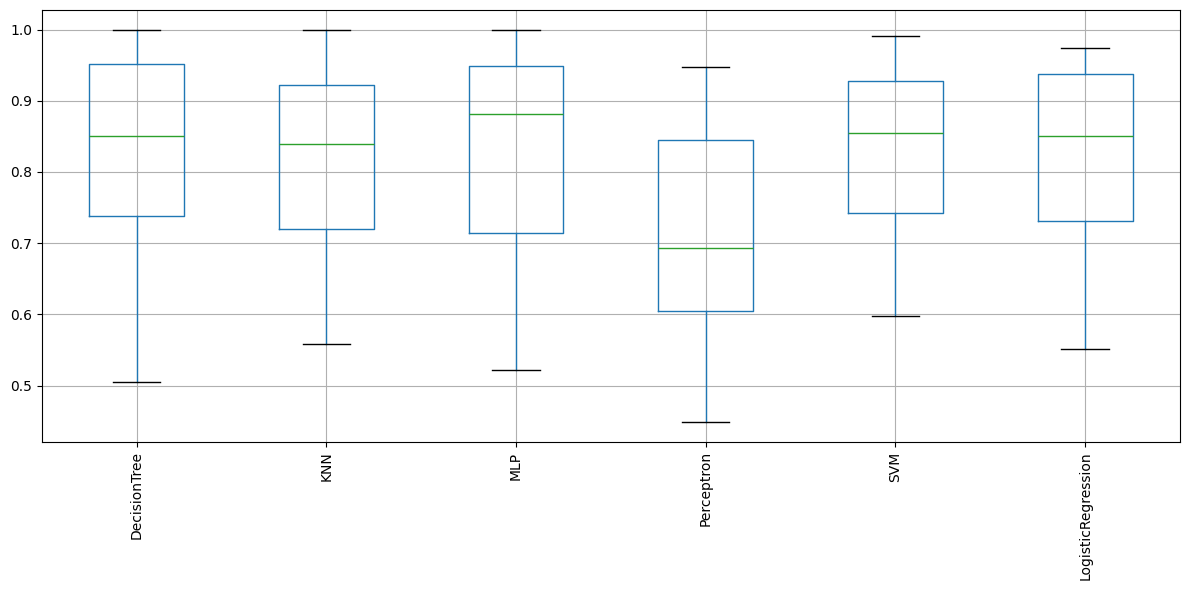

In [62]:
plt.figure(figsize=(12, 6))
final_summary.boxplot(rot=90)
plt.tight_layout()
plt.show()

# Passo 7: Testar diferentes Scallers (Dataset Base)

In [63]:
scalers = {
    'StandardScaler': StandardScaler(),
    'RobustScaler': RobustScaler(),
    'MinMaxScaler': MinMaxScaler()
}

results_with_scalers = {}
y_true_scaled = meta_dataset['Best'].values
loo_scaled = LeaveOneOut()

for scaler_name, scaler in scalers.items():
    summary_of_predictions_scaled = {
        'Dataset': [], 'Best clf (true)': [], 'Perf of best clf (true)': [],
        'Best clf (pred)': [], 'Perf of best clf (pred)': []
    }
    y_pred_scaled = []

    for train_index, test_index in loo_scaled.split(meta_dataset):
        # Split the data into training and test sets
        X = meta_dataset.drop(columns=['Dataset', 'Best'] + classifier_cols)  # Drop everything except meta-features
        y = meta_dataset['Best']
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Scale the features
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Train a simple classifier (e.g., Decision Tree) on the training set
        clf = DecisionTreeClassifier(random_state=42)
        clf.fit(X_train_scaled, y_train)

        # Predict the best classifier for the test dataset
        y_pred_scaled.append(clf.predict(X_test_scaled)[0])

        # Store results in the summary dictionary
        summary_of_predictions_scaled['Dataset'].append(meta_dataset['Dataset'].iloc[test_index].values[0])
        summary_of_predictions_scaled['Best clf (true)'].append(y_test.values[0])
        summary_of_predictions_scaled['Perf of best clf (true)'].append(meta_dataset.loc[test_index, y_test.values[0]].values[0])
        summary_of_predictions_scaled['Best clf (pred)'].append(y_pred_scaled[-1])
        summary_of_predictions_scaled['Perf of best clf (pred)'].append(meta_dataset.loc[test_index, y_pred_scaled[-1]].values[0])

    # Store results for this scaler
    scaler_summary_df = pd.DataFrame(summary_of_predictions_scaled)
    accuracy = accuracy_score(y_true_scaled, y_pred_scaled)
    f1 = f1_score(y_true_scaled, y_pred_scaled, average='weighted')
    results_with_scalers[scaler_name] = {'summary_df': scaler_summary_df, 'accuracy': accuracy, 'f1_score': f1}

    print(f'Meta-model Accuracy ({scaler_name}): {accuracy:.2f}')
    print(f'Meta-model F1-score ({scaler_name}): {f1:.2f}')
    print("-" * 30)

Meta-model Accuracy (StandardScaler): 0.23
Meta-model F1-score (StandardScaler): 0.25
------------------------------
Meta-model Accuracy (RobustScaler): 0.23
Meta-model F1-score (RobustScaler): 0.21
------------------------------
Meta-model Accuracy (MinMaxScaler): 0.18
Meta-model F1-score (MinMaxScaler): 0.20
------------------------------


# Passo 8: Testar diferentes Meta modelos

## Passo 8.1: Neural Network como meta-modelo

In [64]:

class MetaLearningNN(nn.Module):
    """Neural Network for Meta-Learning"""
    def __init__(self, input_size, num_classes=6, dropout=0.2):
        super(MetaLearningNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 32)
        self.dropout1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(32, 16)
        self.dropout2 = nn.Dropout(dropout)
        self.fc3 = nn.Linear(16, num_classes)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout1(x)
        x = self.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)
        return x


class MetaLearningNNClassifier(BaseEstimator, ClassifierMixin):
    """
    Scikit-learn compatible PyTorch Neural Network for Meta-Learning.
    
    Parameters:
    -----------
    dropout : float, default=0.2
        Dropout rate
    learning_rate : float, default=0.001
        Learning rate for optimizer
    epochs : int, default=100
        Number of training epochs
    batch_size : int, default=8
        Batch size for training
    """
    
    def __init__(self, dropout=0.2, 
                 learning_rate=0.001, epochs=100, batch_size=8):
        self.dropout = dropout
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = None
        self.label_encoder = LabelEncoder()
        
    def fit(self, X, y):
        """
        Train the neural network
        
        Parameters:
        -----------
        X : array-like, shape (n_samples, n_features)
            Training data
        y : array-like, shape (n_samples,)
            Target values
        """
        # Convert to numpy if pandas
        if hasattr(X, 'values'):
            X = X.values
        if hasattr(y, 'values'):
            y = y.values
            
        # Encode labels
        y_encoded = self.label_encoder.fit_transform(y)
        
        # Convert to tensors
        X_tensor = torch.FloatTensor(X).to(self.device)
        y_tensor = torch.LongTensor(y_encoded).to(self.device)
        
        # Initialize model
        input_size = X.shape[1]
        num_classes = len(self.label_encoder.classes_)
        
        self.model = MetaLearningNN(
            input_size=input_size,
            num_classes=num_classes,
            dropout=self.dropout
        ).to(self.device)
        
        # Loss and optimizer
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)
        
        # Training loop
        self.model.train()
        dataset = torch.utils.data.TensorDataset(X_tensor, y_tensor)
        dataloader = torch.utils.data.DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
        
        for epoch in range(self.epochs):
            total_loss = 0
            for batch_X, batch_y in dataloader:
                optimizer.zero_grad()
                outputs = self.model(batch_X)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
                
        return self
    
    def predict(self, X):
        """
        Predict class labels
        
        Parameters:
        -----------
        X : array-like, shape (n_samples, n_features)
            Samples
            
        Returns:
        --------
        y_pred : array, shape (n_samples,)
            Predicted class labels
        """
        if self.model is None:
            raise ValueError("Model not fitted yet. Call fit() first.")
            
        # Convert to numpy if pandas
        if hasattr(X, 'values'):
            X = X.values
            
        self.model.eval()
        with torch.no_grad():
            X_tensor = torch.FloatTensor(X).to(self.device)
            outputs = self.model(X_tensor)
            _, predicted = torch.max(outputs, 1)
            predicted = predicted.cpu().numpy()
            
        return self.label_encoder.inverse_transform(predicted)
    
    def predict_proba(self, X):
        """
        Predict class probabilities
        
        Parameters:
        -----------
        X : array-like, shape (n_samples, n_features)
            Samples
            
        Returns:
        --------
        proba : array, shape (n_samples, n_classes)
            Class probabilities
        """
        if self.model is None:
            raise ValueError("Model not fitted yet. Call fit() first.")
            
        # Convert to numpy if pandas
        if hasattr(X, 'values'):
            X = X.values
            
        self.model.eval()
        with torch.no_grad():
            X_tensor = torch.FloatTensor(X).to(self.device)
            outputs = self.model(X_tensor)
            proba = torch.softmax(outputs, dim=1)
            
        return proba.cpu().numpy()


# Example usage:
print("MetaLearningNNClassifier created successfully!")
print(f"Using device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

MetaLearningNNClassifier created successfully!
Using device: cpu


In [65]:
print("="*60)
print("STEP 1: GRID SEARCH WITH 5-FOLD CV - BASE DATASETS")
print("="*60)

# Prepare data
X_base = meta_dataset.drop(columns=['Dataset', 'Best'] + classifier_cols)
y_base = meta_dataset['Best']

# Initialize the classifier
nn_classifier = MetaLearningNNClassifier()

# Perform GridSearchCV with 5-fold cross-validation
# Using a subset of param_grid for efficiency (comment out for full search)
grid_search = GridSearchCV(
    nn_classifier,
    param_grid={
        'dropout': [0.2, 0.3, 0.4],
        'learning_rate': [0.001, 0.005, 0.01],
        'epochs': [30, 50],
        'batch_size': [4, 8, 16]
    },
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',
    verbose=2,
    n_jobs=1  # PyTorch doesn't play well with n_jobs > 1
)

print("\nStarting 5-fold grid search to find best hyperparameters...")
grid_search.fit(X_base, y_base)

print("\n" + "="*60)
print("GRID SEARCH RESULTS")
print("="*60)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best 5-fold CV score: {grid_search.best_score_:.4f}")

# Store best parameters for later use
best_params = grid_search.best_params_
print("\n" + "="*60)
print("STEP 2: TRAINING WITH BEST PARAMS USING LEAVE-ONE-OUT")
print("="*60)
print(f"Using parameters: {best_params}")

STEP 1: GRID SEARCH WITH 5-FOLD CV - BASE DATASETS

Starting 5-fold grid search to find best hyperparameters...
Fitting 5 folds for each of 54 candidates, totalling 270 fits
[CV] END batch_size=4, dropout=0.2, epochs=30, learning_rate=0.001; total time=   0.3s
[CV] END batch_size=4, dropout=0.2, epochs=30, learning_rate=0.001; total time=   0.2s
[CV] END batch_size=4, dropout=0.2, epochs=30, learning_rate=0.001; total time=   0.2s
[CV] END batch_size=4, dropout=0.2, epochs=30, learning_rate=0.001; total time=   0.2s
[CV] END batch_size=4, dropout=0.2, epochs=30, learning_rate=0.001; total time=   0.2s
[CV] END batch_size=4, dropout=0.2, epochs=30, learning_rate=0.005; total time=   0.2s
[CV] END batch_size=4, dropout=0.2, epochs=30, learning_rate=0.005; total time=   0.2s
[CV] END batch_size=4, dropout=0.2, epochs=30, learning_rate=0.005; total time=   0.2s
[CV] END batch_size=4, dropout=0.2, epochs=30, learning_rate=0.005; total time=   0.2s
[CV] END batch_size=4, dropout=0.2, epochs=

In [66]:
# Evaluate Neural Network with Leave-One-Out on base datasets
print("="*60)
print("NEURAL NETWORK EVALUATION - LEAVE-ONE-OUT (BASE DATASETS)")
print("="*60)

# Create a dictionary to store the results
nn_summary_predictions = {
    'Dataset': [], 
    'Best clf (true)': [], 
    'Perf of best clf (true)': [],
    'Best clf (pred)': [], 
    'Perf of best clf (pred)': []
}

loo = LeaveOneOut()
y_true_nn = meta_dataset['Best'].values
y_pred_nn = []

for train_index, test_index in loo.split(meta_dataset):
    # Split the data into training and test sets
    X = meta_dataset.drop(columns=['Dataset', 'Best'] + classifier_cols)
    y = meta_dataset['Best']
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train the Neural Network with best parameters from grid search
    nn_clf = MetaLearningNNClassifier(**best_params)
    nn_clf.fit(X_train, y_train)
    
    # Predict the best classifier for the test dataset
    prediction = nn_clf.predict(X_test)[0]
    y_pred_nn.append(prediction)
    
    # Store results in the summary dictionary
    nn_summary_predictions['Dataset'].append(meta_dataset['Dataset'].iloc[test_index].values[0])
    nn_summary_predictions['Best clf (true)'].append(y_test.values[0])
    nn_summary_predictions['Perf of best clf (true)'].append(
        meta_dataset.loc[test_index, y_test.values[0]].values[0]
    )
    nn_summary_predictions['Best clf (pred)'].append(prediction)
    nn_summary_predictions['Perf of best clf (pred)'].append(
        meta_dataset.loc[test_index, prediction].values[0]
    )

# Create a DataFrame from the summary of predictions
nn_base_summary_df = pd.DataFrame(nn_summary_predictions)

# Calculate meta-model accuracy and F1-score
nn_base_accuracy = accuracy_score(y_true_nn, y_pred_nn)
nn_base_f1 = f1_score(y_true_nn, y_pred_nn, average='weighted')

print(f'\nNeural Network Meta-model Accuracy: {nn_base_accuracy:.4f}')
print(f'Neural Network Meta-model F1-score: {nn_base_f1:.4f}')
print(f'\nComparison with Decision Tree:')
print(f'  Decision Tree Accuracy: {base_meta_model_accuracy_no_scaler:.4f}')
print(f'  Neural Network Accuracy: {nn_base_accuracy:.4f}')
print(f'  Improvement: {(nn_base_accuracy - base_meta_model_accuracy_no_scaler):.4f}')
nn_base_summary_df.describe()

NEURAL NETWORK EVALUATION - LEAVE-ONE-OUT (BASE DATASETS)

Neural Network Meta-model Accuracy: 0.2727
Neural Network Meta-model F1-score: 0.1169

Comparison with Decision Tree:
  Decision Tree Accuracy: 0.2273
  Neural Network Accuracy: 0.2727
  Improvement: 0.0455


,Perf of best clf (true),Perf of best clf (pred)
count,22.000000,22.000000
mean,0.893706,0.839992
std,0.094076,0.114005
min,0.718700,0.638093
25%,0.812109,0.749877
50%,0.925093,0.849455
75%,0.964050,0.910257
max,1.000000,1.000000


In [67]:
print("="*60)
print("STEP 1: GRID SEARCH WITH 5-FOLD CV - ALL DATASETS")
print("="*60)

# Prepare data
X_base = complete_meta_dataset.drop(columns=['Dataset', 'Best'] + classifier_cols)
y_base = complete_meta_dataset['Best']

# Initialize the classifier
nn_classifier = MetaLearningNNClassifier()

# Perform GridSearchCV with 5-fold cross-validation
# Using a subset of param_grid for efficiency (comment out for full search)
grid_search = GridSearchCV(
    nn_classifier,
    param_grid={
        'dropout': [0.2, 0.3, 0.4],
        'learning_rate': [0.001, 0.005, 0.01],
        'epochs': [30, 50],
        'batch_size': [4, 8, 16]
    },
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',
    verbose=2,
    n_jobs=1  # PyTorch doesn't play well with n_jobs > 1
)

print("\nStarting 5-fold grid search to find best hyperparameters...")
grid_search.fit(X_base, y_base)

print("\n" + "="*60)
print("GRID SEARCH RESULTS")
print("="*60)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best 5-fold CV score: {grid_search.best_score_:.4f}")

# Store best parameters for later use
best_params = grid_search.best_params_
print("\n" + "="*60)
print("STEP 2: TRAINING WITH BEST PARAMS USING LEAVE-ONE-OUT")
print("="*60)
print(f"Using parameters: {best_params}")

STEP 1: GRID SEARCH WITH 5-FOLD CV - ALL DATASETS

Starting 5-fold grid search to find best hyperparameters...
Fitting 5 folds for each of 54 candidates, totalling 270 fits
[CV] END batch_size=4, dropout=0.2, epochs=30, learning_rate=0.001; total time=   0.3s
[CV] END batch_size=4, dropout=0.2, epochs=30, learning_rate=0.001; total time=   0.2s
[CV] END batch_size=4, dropout=0.2, epochs=30, learning_rate=0.001; total time=   0.2s
[CV] END batch_size=4, dropout=0.2, epochs=30, learning_rate=0.001; total time=   0.4s
[CV] END batch_size=4, dropout=0.2, epochs=30, learning_rate=0.001; total time=   0.4s
[CV] END batch_size=4, dropout=0.2, epochs=30, learning_rate=0.005; total time=   0.3s
[CV] END batch_size=4, dropout=0.2, epochs=30, learning_rate=0.005; total time=   0.1s
[CV] END batch_size=4, dropout=0.2, epochs=30, learning_rate=0.005; total time=   0.2s
[CV] END batch_size=4, dropout=0.2, epochs=30, learning_rate=0.005; total time=   0.2s
[CV] END batch_size=4, dropout=0.2, epochs=3

In [68]:
# Evaluate Neural Network with Leave-One-Out on base datasets
print("="*60)
print("NEURAL NETWORK EVALUATION - LEAVE-ONE-OUT (ALL DATASETS)")
print("="*60)

# Create a dictionary to store the results
nn_summary_predictions = {
    'Dataset': [], 
    'Best clf (true)': [], 
    'Perf of best clf (true)': [],
    'Best clf (pred)': [], 
    'Perf of best clf (pred)': []
}

loo = LeaveOneOut()
y_true_nn = complete_meta_dataset['Best'].values
y_pred_nn = []

for train_index, test_index in loo.split(complete_meta_dataset):
    # Split the data into training and test sets
    X = complete_meta_dataset.drop(columns=['Dataset', 'Best'] + classifier_cols)
    y = complete_meta_dataset['Best']
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train the Neural Network with best parameters from grid search
    nn_clf = MetaLearningNNClassifier(**best_params)
    nn_clf.fit(X_train, y_train)
    
    # Predict the best classifier for the test dataset
    prediction = nn_clf.predict(X_test)[0]
    y_pred_nn.append(prediction)
    
    # Store results in the summary dictionary
    nn_summary_predictions['Dataset'].append(complete_meta_dataset['Dataset'].iloc[test_index].values[0])
    nn_summary_predictions['Best clf (true)'].append(y_test.values[0])
    nn_summary_predictions['Perf of best clf (true)'].append(
        complete_meta_dataset.loc[test_index, y_test.values[0]].values[0]
    )
    nn_summary_predictions['Best clf (pred)'].append(prediction)
    nn_summary_predictions['Perf of best clf (pred)'].append(
        complete_meta_dataset.loc[test_index, prediction].values[0]
    )

# Create a DataFrame from the summary of predictions
nn_complete_summary_df = pd.DataFrame(nn_summary_predictions)

# Calculate meta-model accuracy and F1-score
nn_complete_accuracy = accuracy_score(y_true_nn, y_pred_nn)
nn_complete_f1 = f1_score(y_true_nn, y_pred_nn, average='weighted')

print(f'\nNeural Network Meta-model Accuracy: {nn_complete_accuracy:.4f}')
print(f'Neural Network Meta-model F1-score: {nn_complete_f1:.4f}')
print(f'\nComparison with Decision Tree:')
print(f'  Decision Tree Accuracy: {complete_meta_model_accuracy:.4f}')
print(f'  Neural Network Accuracy: {nn_complete_accuracy:.4f}')
print(f'  Improvement: {(nn_complete_accuracy - complete_meta_model_accuracy):.4f}')
nn_complete_summary_df.describe()

NEURAL NETWORK EVALUATION - LEAVE-ONE-OUT (ALL DATASETS)

Neural Network Meta-model Accuracy: 0.2647
Neural Network Meta-model F1-score: 0.1108

Comparison with Decision Tree:
  Decision Tree Accuracy: 0.1471
  Neural Network Accuracy: 0.2647
  Improvement: 0.1176


,Perf of best clf (true),Perf of best clf (pred)
count,34.000000,34.000000
mean,0.884787,0.839199
std,0.107216,0.127007
min,0.606507,0.505419
25%,0.794247,0.738296
50%,0.925035,0.850525
75%,0.972358,0.951302
max,1.000000,1.000000


## Passo 8.2: SVM como meta-modelo

In [69]:
# SVM meta-model with scaler search + hyperparameter grid search (Base datasets)

print("=" * 70)
print("SVM META-MODEL: SCALERS + GRID SEARCH (BASE DATASETS)")
print("=" * 70)

# Meta-features (X) and target best classifier label (y)
X_svm = meta_dataset.drop(columns=['Dataset', 'Best'] + classifier_cols)
y_svm = meta_dataset['Best']

# Pipeline: impute -> scale -> SVM
svm_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('svc', SVC(random_state=42))
])

# Grid search over scalers + SVM hyperparameters
param_grid = {
    'scaler': [StandardScaler(), RobustScaler(), MinMaxScaler()],
    'svc__C': [0.1, 1, 10, 100],
    'svc__kernel': ['linear', 'rbf'],
    'svc__gamma': ['scale', 'auto'],
    'svc__class_weight': [None, 'balanced']
}

n_candidates = len(list(ParameterGrid(param_grid)))
n_folds = len(meta_dataset)  # LOO folds
total_grid_fits = n_candidates * n_folds
print(f"Planned GridSearch fits: {total_grid_fits} ({n_candidates} configs x {n_folds} folds)")

# Use LOO because number of meta-instances is small
grid_search_svm = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    cv=LeaveOneOut(),
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

print("Starting grid search...")
grid_search_svm.fit(X_svm, y_svm)

best_svm_meta_model = grid_search_svm.best_estimator_
best_svm_params = grid_search_svm.best_params_
best_svm_cv_acc = grid_search_svm.best_score_

print("\nBest SVM params:")
print(best_svm_params)
print(f"Best CV accuracy (LOO): {best_svm_cv_acc:.4f}")

# LOO evaluation with the best model (for full prediction summary)
loo = LeaveOneOut()
svm_summary_predictions = {
    'Dataset': [],
    'Best clf (true)': [],
    'Perf of best clf (true)': [],
    'Best clf (pred)': [],
    'Perf of best clf (pred)': []
}

y_true_svm = meta_dataset['Best'].values
y_pred_svm = []
n_loo_fits = len(meta_dataset)
t0 = time()

for fit_idx, (train_index, test_index) in enumerate(loo.split(meta_dataset), start=1):
    X_train, X_test = X_svm.iloc[train_index], X_svm.iloc[test_index]
    y_train, y_test = y_svm.iloc[train_index], y_svm.iloc[test_index]

    best_svm_meta_model.fit(X_train, y_train)
    pred = best_svm_meta_model.predict(X_test)[0]
    y_pred_svm.append(pred)

    elapsed = time() - t0
    avg_time = elapsed / fit_idx
    eta = avg_time * (n_loo_fits - fit_idx)
    print(f"[LOO] fit {fit_idx}/{n_loo_fits} | elapsed: {elapsed:.1f}s | ETA: {eta:.1f}s")

    svm_summary_predictions['Dataset'].append(meta_dataset['Dataset'].iloc[test_index].values[0])
    svm_summary_predictions['Best clf (true)'].append(y_test.values[0])
    svm_summary_predictions['Perf of best clf (true)'].append(meta_dataset.loc[test_index, y_test.values[0]].values[0])
    svm_summary_predictions['Best clf (pred)'].append(pred)
    svm_summary_predictions['Perf of best clf (pred)'].append(meta_dataset.loc[test_index, pred].values[0])

svm_base_summary_df = pd.DataFrame(svm_summary_predictions)
svm_base_accuracy = accuracy_score(y_true_svm, y_pred_svm)
svm_base_f1 = f1_score(y_true_svm, y_pred_svm, average='weighted')

print("\n" + "=" * 70)
print("SVM META-MODEL RESULTS (BASE DATASETS)")
print("=" * 70)
print(f"Accuracy: {svm_base_accuracy:.4f}")
print(f"F1-score: {svm_base_f1:.4f}")

if 'base_meta_model_accuracy_no_scaler' in globals():
    print("-" * 70)
    print(f"Decision Tree (base, no scaler) accuracy: {base_meta_model_accuracy_no_scaler:.4f}")
    print(f"SVM meta-model accuracy: {svm_base_accuracy:.4f}")
    print(f"Difference (SVM - DT): {(svm_base_accuracy - base_meta_model_accuracy_no_scaler):.4f}")

svm_base_summary_df

SVM META-MODEL: SCALERS + GRID SEARCH (BASE DATASETS)
Planned GridSearch fits: 2112 (96 configs x 22 folds)
Starting grid search...
Fitting 22 folds for each of 96 candidates, totalling 2112 fits
[CV] END scaler=StandardScaler(), svc__C=0.1, svc__class_weight=None, svc__gamma=scale, svc__kernel=linear; total time=   0.0s
[CV] END scaler=StandardScaler(), svc__C=0.1, svc__class_weight=None, svc__gamma=scale, svc__kernel=linear; total time=   0.0s
[CV] END scaler=StandardScaler(), svc__C=0.1, svc__class_weight=None, svc__gamma=scale, svc__kernel=linear; total time=   0.0s
[CV] END scaler=StandardScaler(), svc__C=0.1, svc__class_weight=None, svc__gamma=scale, svc__kernel=linear; total time=   0.0s
[CV] END scaler=StandardScaler(), svc__C=0.1, svc__class_weight=None, svc__gamma=scale, svc__kernel=linear; total time=   0.0s
[CV] END scaler=StandardScaler(), svc__C=0.1, svc__class_weight=None, svc__gamma=scale, svc__kernel=linear; total time=   0.0s
[CV] END scaler=StandardScaler(), svc__C=0

,Dataset,Best clf (true),Perf of best clf (true),Best clf (pred),Perf of best clf (pred)
0,autoUniv-au1-1000,SVM,0.758000,DecisionTree,0.649000
1,blood-transfusion-service-center,LogisticRegression,0.772707,LogisticRegression,0.772707
2,cnae-9,MLP,0.955556,MLP,0.955556
3,diabetes,LogisticRegression,0.770792,LogisticRegression,0.770792
4,ibm-employee-performance,DecisionTree,1.000000,DecisionTree,1.000000
5,ilpd-numeric,LogisticRegression,0.718700,LogisticRegression,0.718700
6,isolet,MLP,0.961396,MLP,0.961396
7,kr-vs-kp,DecisionTree,0.995620,DecisionTree,0.995620
8,monks-problems-2,DecisionTree,0.991667,SVM,0.677204
9,mushroom,DecisionTree,1.000000,DecisionTree,1.000000


# Passo 9: Comparar Resultados

In [70]:
# Create comparison table including COMPLETE dataset and SVM meta-model results (if available)
models_data = {
    'Model': [
        'Decision Tree (Base, No Scaler)',
        'Decision Tree (Base, StandardScaler)',
        'Decision Tree (Base, RobustScaler)',
        'Decision Tree (Base, MinMaxScaler)',
        'Neural Network (Base)',
        'Decision Tree (Complete)',
        'Neural Network (Complete)',
        'SVM Meta-model (Base)'
    ],
    'Dataset Size': [
        len(meta_dataset), len(meta_dataset), len(meta_dataset), len(meta_dataset),
        len(meta_dataset), len(complete_meta_dataset), len(complete_meta_dataset), 
        len(meta_dataset) 
    ],
    'Accuracy': [
        base_meta_model_accuracy_no_scaler,
        results_with_scalers['StandardScaler']['accuracy'],
        results_with_scalers['RobustScaler']['accuracy'],
        results_with_scalers['MinMaxScaler']['accuracy'],
        nn_base_accuracy,
        complete_meta_model_accuracy,
        nn_complete_accuracy,
        svm_base_accuracy
    ],
    'F1-Score': [
        base_meta_model_f1_no_scaler,
        results_with_scalers['StandardScaler']['f1_score'],
        results_with_scalers['RobustScaler']['f1_score'],
        results_with_scalers['MinMaxScaler']['f1_score'],
        nn_base_f1,
        complete_meta_model_f1,
        nn_complete_f1,
        svm_base_f1
    ]
}

complete_comparison_df = pd.DataFrame(models_data)

print("=" * 80)
print("MODEL COMPARISON TABLE")
print("=" * 80)
print(complete_comparison_df.to_string(index=False))
print("=" * 80)

if 'svm_base_accuracy' not in globals():
    print("Run the SVM Base cell first to include SVM Base results.")
if 'svm_complete_accuracy' not in globals():
    print("Run the SVM Complete cell first to include SVM Complete results.")

# Order by accuracy
complete_comparison_df = complete_comparison_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

# Display as DataFrame
complete_comparison_df

MODEL COMPARISON TABLE
                               Model  Dataset Size  Accuracy  F1-Score
     Decision Tree (Base, No Scaler)            22  0.227273  0.213039
Decision Tree (Base, StandardScaler)            22  0.227273  0.251623
  Decision Tree (Base, RobustScaler)            22  0.227273  0.213039
  Decision Tree (Base, MinMaxScaler)            22  0.181818  0.203988
               Neural Network (Base)            22  0.272727  0.116883
            Decision Tree (Complete)            34  0.147059  0.135714
           Neural Network (Complete)            34  0.264706  0.110807
               SVM Meta-model (Base)            22  0.545455  0.527548
Run the SVM Complete cell first to include SVM Complete results.


,Model,Dataset Size,Accuracy,F1-Score
0,SVM Meta-model (Base),22,0.545455,0.527548
1,Neural Network (Base),22,0.272727,0.116883
2,Neural Network (Complete),34,0.264706,0.110807
3,"Decision Tree (Base, No Scaler)",22,0.227273,0.213039
4,"Decision Tree (Base, StandardScaler)",22,0.227273,0.251623
5,"Decision Tree (Base, RobustScaler)",22,0.227273,0.213039
6,"Decision Tree (Base, MinMaxScaler)",22,0.181818,0.203988
7,Decision Tree (Complete),34,0.147059,0.135714
